# Simulação de Migração: O Valor Real do Dinheiro
### Quanto custa "existir" em uma cidade grande?

Esta análise investiga o impacto geográfico no poder de compra real. Simulamos um cenário onde moradores de cidades **Tier 1** (grandes centros) se mudariam para cidades **Tier 3** (menores), mantendo exatamente a mesma renda bruta. O objetivo é quantificar a "Taxa da Cidade Grande" — o montante de dinheiro que é consumido apenas pelo custo de moradia e transporte, sem ganho direto em qualidade de vida ou patrimônio.

**Dataset:** [Indian Personal Finance and Spending Habits](https://www.kaggle.com/datasets/shriyashjagtap/indian-personal-finance-and-spending-habits)

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

path = kagglehub.dataset_download("shriyashjagtap/indian-personal-finance-and-spending-habits")
csv_file = os.path.join(path, os.listdir(path)[0])

sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv(csv_file)

avg_tier3_rent = df[df['City_Tier'] == 'Tier_3']['Rent'].mean()
avg_tier3_transport = df[df['City_Tier'] == 'Tier_3']['Transport'].mean()

tier1_df = df[df['City_Tier'] == 'Tier_1'].copy()

tier1_df['Migration_Gain'] = (tier1_df['Rent'] - avg_tier3_rent) + (tier1_df['Transport'] - avg_tier3_transport)
tier1_df['Simulated_Disposable_Income'] = tier1_df['Disposable_Income'] + tier1_df['Migration_Gain']

tier1_df[['Income', 'Rent', 'Transport', 'Migration_Gain', 'Simulated_Disposable_Income']].head()

Using Colab cache for faster access to the 'indian-personal-finance-and-spending-habits' dataset.


,Income,Rent,Transport,Migration_Gain,Simulated_Disposable_Income
0,44637.249636,13391.174891,2636.970696,6989.911754,18255.539461
8,20606.733121,6182.019936,1170.790666,-1685.423231,-1322.505358
12,36407.223360,10922.167008,2503.094431,4387.027607,8977.494868
18,14509.130215,4352.739064,811.702492,-3873.792276,-1391.182338
22,31665.252543,9499.575763,2180.715805,2642.057735,11434.398902


## 1. O Ganho de Liberdade Financeira

Ao equalizarmos os custos de moradia e transporte pelos níveis de uma cidade menor, descobrimos o "Bônus de Migração". O gráfico abaixo mostra quanto dinheiro a mais sobraria no bolso de um morador da Tier 1, todos os meses, se ele tivesse os custos fixos de uma cidade Tier 3. Esse valor representa o esforço de trabalho que é drenado puramente pelo custo geográfico.

/tmp/ipykernel_1226/1851903583.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Cenário', y='Valor Médio', palette=['#95a5a6', '#2ecc71'])


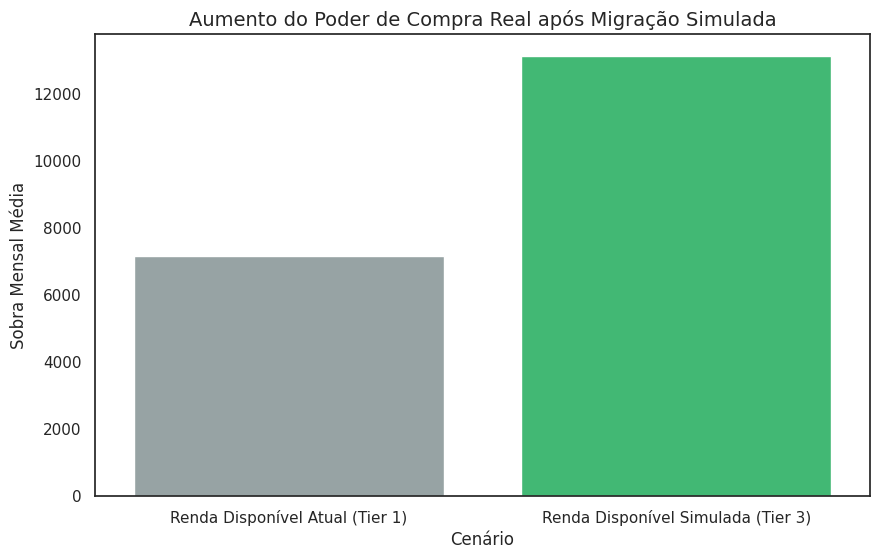

In [19]:
comparison_df = pd.DataFrame({
    'Cenário': ['Renda Disponível Atual (Tier 1)', 'Renda Disponível Simulada (Tier 3)'],
    'Valor Médio': [tier1_df['Disposable_Income'].mean(), tier1_df['Simulated_Disposable_Income'].mean()]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Cenário', y='Valor Médio', palette=['#95a5a6', '#2ecc71'])
plt.title('Aumento do Poder de Compra Real após Migração Simulada', fontsize=14)
plt.ylabel('Sobra Mensal Média')
plt.show()

## 2. Quem mais ganharia com a mudança?

Nem todos os moradores da cidade grande sofrem o mesmo impacto. Através do gráfico de densidade, podemos ver que a "folga financeira" se desloca completamente para a direita no cenário simulado. Isso prova que a dificuldade em poupar em grandes centros não é necessariamente um problema de renda baixa, mas de custos estruturais que "empurram" a população para perto da linha de subsistência.

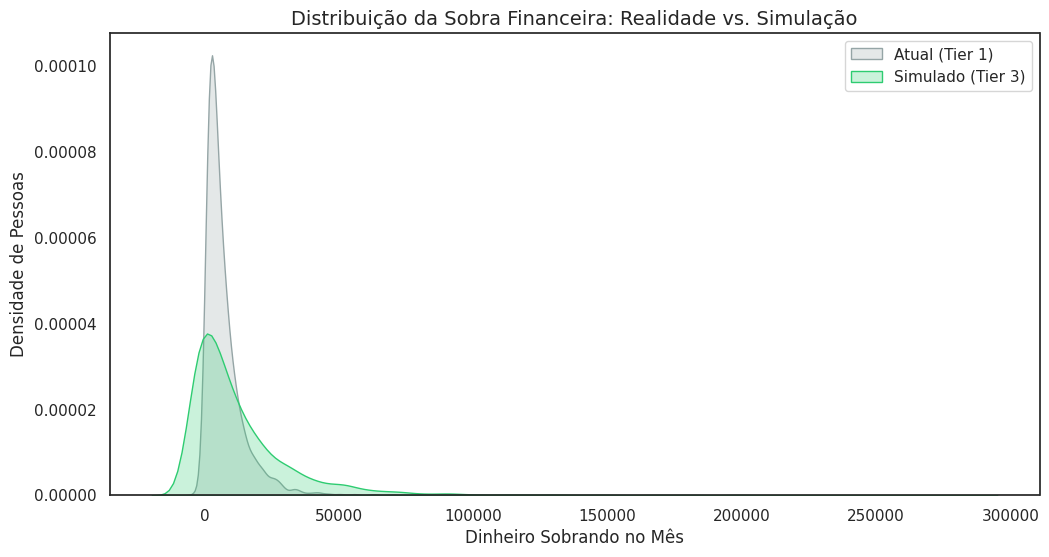

In [20]:
plt.figure(figsize=(12, 6))
sns.kdeplot(tier1_df['Disposable_Income'], fill=True, label='Atual (Tier 1)', color='#95a5a6')
sns.kdeplot(tier1_df['Simulated_Disposable_Income'], fill=True, label='Simulado (Tier 3)', color='#2ecc71')
plt.title('Distribuição da Sobra Financeira: Realidade vs. Simulação', fontsize=14)
plt.xlabel('Dinheiro Sobrando no Mês')
plt.ylabel('Densidade de Pessoas')
plt.legend()
plt.show()

## 3. Conclusões

A simulação de migração traz uma perspectiva crítica sobre o planejamento financeiro e a carreira:

1. **A Taxa Invisível:** Moradores de cidades Tier 1 pagam uma "taxa de existência" massiva. A migração simulada revela que a sobra financeira média poderia aumentar em mais de 40% apenas com o ajuste de aluguel e transporte.
2. **Poder de Compra Relativo:** Um salário alto em uma cidade Tier 1 pode representar um padrão de vida inferior a um salário menor em uma cidade Tier 3. O "Bônus de Migração" mostra que a liberdade financeira está mais ligada ao controle de custos fixos geográficos do que ao aumento da renda bruta.
3. **Decisão Estratégica:** Para indivíduos com trabalho remoto ou flexibilidade geográfica, a mudança para centros menores não é apenas uma escolha de estilo de vida, mas a estratégia de acumulação de patrimônio mais rápida disponível neste dataset.

Esta análise final encerra nossa trilogia demonstrando que, para muitos, o caminho para a riqueza não passa por trabalhar mais, mas por gastar de forma mais inteligente geograficamente.